## Título :

El proceso de Ciencia de Datos.

---




**Descripción:**

El objetivo de este ejercicio es comprender todos los pasos involucrados en un entorno de ciencia de datos.

**Descripción de los datos:**

Hubway era el programa público de bicicletas compartidas del área metropolitana de Boston, con más de 1600 bicicletas en más de 160 estaciones en el área metropolitana de Boston. Hubway era propiedad de cuatro municipios de la zona.

Para 2016, Hubway operaba 185 estaciones y 1750 bicicletas, con 5 millones de viajes desde su lanzamiento en 2011.

En abril de 2017, Hubway organizó un Desafío de Visualización de Datos en el Centro Microsoft NERD de Cambridge, donde publicó 5 años de datos de viajes.


**Instrucciones:**


*   Lea los archivos de datos *hubway_stations.csv* y *hubway_trips.csv* en dataframes de Pandas separados.
*   Obtenga una visión general rápida de las columnas presentes en los datos y sus tipos.
*   Elimina todos los registros que contengan valores nulos en una o más columnas.
*   Cree una nueva columna, "age", que calcule la edad del ciclista a partir de su fecha de nacimiento.
*   Realice un Análisis Exploratorio de Datos (ADE) para responder a las preguntas inicialmente planteadas.
*   Cree un modelo lineal simple para predecir el número de alquileres en función de la distancia de las bicicletas al centro de la ciudad.
*   Visualice la predicción con los datos.


**Pistas:**

*   *pd.read_csv(filename)*: Devuelve un dataframe de Pandas que contiene los datos y las etiquetas del archivo.

*   *pd.describe()*: Genera estadísticas descriptivas del dataframe.

*   *pd.dropna()*: Elimina los valores faltantes (nulos) del dataframe. Elimina las columnas o filas según el parámetro del axis (eje).



In [55]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from math import radians, cos, sin, asin, sqrt
from sklearn.linear_model import LinearRegression
from typing import List
from typing import Tuple

%matplotlib inline

# **Primera vista a los datos**

In [2]:
# Read the data from the file "hubway_stations.csv"

stations: pd.DataFrame = pd.read_csv("dataset/hubway_stations.csv")

# Read the data from the file "hubway_trips.csv"
trips: pd.DataFrame = pd.read_csv("dataset/hubway_trips.csv")

### **INSPECCIONAREMOS UN POCO MAS ACERCA DE "STATIONS"**
- stations.head(20)
- stations.info()
- stations.shape
- stations.describe()
- columns_stations: List[str] = stations.columns.to_list()

In [68]:
stations.head(20)

,id,terminal,station,municipal,lat,lng,status
0,3,B32006,Colleges of the Fenway,Boston,42.340021,-71.100812,Existing
1,4,C32000,Tremont St. at Berkeley St.,Boston,42.345392,-71.069616,Existing
2,5,B32012,Northeastern U / North Parking Lot,Boston,42.341814,-71.090179,Existing
3,6,D32000,Cambridge St. at Joy St.,Boston,42.361285,-71.065140,Existing
4,7,A32000,Fan Pier,Boston,42.353412,-71.044624,Existing
5,8,A32001,Union Square - Brighton Ave. at Cambridge St.,Boston,42.353334,-71.137313,Existing
6,9,A32002,Agganis Arena - 925 Comm Ave.,Boston,42.351313,-71.116174,Existing
7,10,A32003,B.U. Central - 725 Comm. Ave.,Boston,42.350075,-71.105884,Existing
8,11,A32004,Longwood Ave / Binney St,Boston,42.338629,-71.106500,Existing
9,12,B32002,Ruggles Station / Columbus Ave.,Boston,42.335911,-71.088496,Existing


In [69]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         142 non-null    int64  
 1   terminal   142 non-null    object 
 2   station    142 non-null    object 
 3   municipal  142 non-null    object 
 4   lat        142 non-null    float64
 5   lng        142 non-null    float64
 6   status     142 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 7.9+ KB


In [70]:
print(stations.shape)

(142, 7)


In [71]:
stations.describe()

,id,lat,lng
count,142.000000,142.000000,142.000000
mean,74.323944,42.354820,-71.089087
std,41.389098,0.020089,0.027111
min,3.000000,42.309467,-71.146452
25%,39.250000,42.341652,-71.113183
50%,74.500000,42.353373,-71.089191
75%,109.750000,42.366265,-71.065210
max,145.000000,42.404490,-71.035705


In [72]:
columns_stations: List[str] = stations.columns.to_list()
print(columns_stations)

['id', 'terminal', 'station', 'municipal', 'lat', 'lng', 'status']


### **INSPECCIONAREMOS UN POCO MAS ACERCA DE "TRIPS"**
- trips.head(20)
- trips.info()
- trips.shape
- trips.describe()
- columns_trips: List[str] = trips.columns.to_list()

In [3]:
trips.head(20)

,seq_id,hubway_id,status,duration,start_date,strt_statn,end_date,end_statn,bike_nr,subsc_type,zip_code,birth_date,gender
0,1,8,Closed,9,7/28/2011 10:12:00,23.0,7/28/2011 10:12:00,23.0,B00468,Registered,'97217,1976.0,Male
1,2,9,Closed,220,7/28/2011 10:21:00,23.0,7/28/2011 10:25:00,23.0,B00554,Registered,'02215,1966.0,Male
2,3,10,Closed,56,7/28/2011 10:33:00,23.0,7/28/2011 10:34:00,23.0,B00456,Registered,'02108,1943.0,Male
3,4,11,Closed,64,7/28/2011 10:35:00,23.0,7/28/2011 10:36:00,23.0,B00554,Registered,'02116,1981.0,Female
4,5,12,Closed,12,7/28/2011 10:37:00,23.0,7/28/2011 10:37:00,23.0,B00554,Registered,'97214,1983.0,Female
5,6,13,Closed,19,7/28/2011 10:39:00,23.0,7/28/2011 10:39:00,23.0,B00456,Registered,'02021,1951.0,Male
6,7,14,Closed,24,7/28/2011 10:47:00,23.0,7/28/2011 10:47:00,23.0,B00554,Registered,'02140,1971.0,Female
7,8,15,Closed,7,7/28/2011 10:48:00,23.0,7/28/2011 10:48:00,23.0,B00554,Registered,'02140,1971.0,Female
8,9,16,Closed,8,7/28/2011 11:01:00,23.0,7/28/2011 11:01:00,23.0,B00554,Registered,'97214,1983.0,Female
9,10,17,Closed,1108,7/28/2011 11:55:00,47.0,7/28/2011 12:13:00,40.0,B00550,Registered,'01867,1994.0,Male


In [4]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


In [5]:
print(trips.shape)

(1579025, 13)


In [6]:
trips.describe()

,seq_id,hubway_id,duration,strt_statn,end_statn,birth_date
count,1.579025e+06,1.579025e+06,1.579025e+06,1.579011e+06,1.578980e+06,350644.000000
mean,7.895130e+05,8.865317e+05,1.200280e+03,5.438039e+01,5.425603e+01,1976.295322
std,4.558254e+05,5.064783e+05,2.653539e+04,3.364295e+01,3.347219e+01,10.999742
min,1.000000e+00,8.000000e+00,-6.900000e+03,3.000000e+00,3.000000e+00,1932.000000
25%,3.947570e+05,4.465250e+05,4.120000e+02,2.700000e+01,2.900000e+01,1969.000000
50%,7.895130e+05,8.950440e+05,6.600000e+02,4.800000e+01,4.800000e+01,1979.000000
75%,1.184269e+06,1.328083e+06,1.082000e+03,7.400000e+01,7.400000e+01,1985.000000
max,1.579025e+06,1.748022e+06,1.199446e+07,1.450000e+02,1.450000e+02,1995.000000


In [7]:
columns_trips: List[str] = trips.columns.to_list()
print(columns_trips)

['seq_id', 'hubway_id', 'status', 'duration', 'start_date', 'strt_statn', 'end_date', 'end_statn', 'bike_nr', 'subsc_type', 'zip_code', 'birth_date', 'gender']


In [8]:
# Take a quick look at the stations data
stations.head(20)
stations[stations['terminal'] == 'C32002']
stations['municipal'].value_counts().to_frame()

,count
municipal,
Boston,97
Cambridge,28
Somerville,12
Brookline,5


### **ENTENDIENDO TODOS LOS DATOS "STATIONS"**

Es importante comprender completamente toda la información proporcionada en los datos. El primer paso es examinar con más detalle todas las columnas y comprender sus tipos.

<div style="border-left: 5px solid blue; background-color: #e6f0ff; padding:10px;">
<strong>Mensaje Inicial:</strong> A continuación se hara la exploración e intepretación de cada una de los 7 columnas de "stations"
</div>

#### **Exploración de stations**

In [82]:
# Getting the data type of each column in the stations data
stations.dtypes

id             int64
terminal      object
station       object
municipal     object
lat          float64
lng          float64
status        object
dtype: object

**Explorando la columna "id"**

In [86]:
stations.info()
# Count how many times each 'id' appears and convert the result to a DataFrame
id_counts: pd.DataFrame = stations["id"].value_counts().to_frame()
id_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         142 non-null    int64  
 1   terminal   142 non-null    object 
 2   station    142 non-null    object 
 3   municipal  142 non-null    object 
 4   lat        142 non-null    float64
 5   lng        142 non-null    float64
 6   status     142 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 7.9+ KB


,count
id,
3,1
4,1
5,1
6,1
7,1
...,...
141,1
142,1
143,1


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación:</strong> Vemos que el atributo "id" tienen valores únicos, ya que la frecuencia de cada una de ellas es 1.
</div>

**Explorando la columna "terminal"**

In [96]:
stations.info()
# Generate a frequency table for 'terminal' values:
# Useful for understanding how terminal identifiers are distributed
# and identifying repeated or dominant terminals in the dataset.
terminal_counts: pd.DataFrame = stations["terminal"].value_counts().to_frame()
terminal_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         142 non-null    int64  
 1   terminal   142 non-null    object 
 2   station    142 non-null    object 
 3   municipal  142 non-null    object 
 4   lat        142 non-null    float64
 5   lng        142 non-null    float64
 6   status     142 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 7.9+ KB


,count
terminal,
D32004,2
D32003,2
C32002,2
K32002,2
M32015,2
...,...
S32008,1
S32009,1
S32010,1


In [102]:
# En este momento "terminal" esta como index y solo "count" como columna
print(terminal_counts.index)
print(terminal_counts.columns)

Index(['D32004', 'D32003', 'C32002', 'K32002', 'M32015', 'C32012', 'B32008',
       'D32001', 'B32017', 'C32008',
       ...
       'M32027', 'M32029', 'S32005', 'S32006', 'S32007', 'S32008', 'S32009',
       'S32010', 'S32011', 'S32012'],
      dtype='object', name='terminal', length=131)
Index(['count'], dtype='object')


In [109]:
terminal_counts.columns = ["count"]
# Count how many terminals have frequency 2 and 1
count_freq_2: int = int((terminal_counts["count"] == 2).sum())
count_freq_1: int = int((terminal_counts["count"] == 1).sum())
print(count_freq_2)
print(count_freq_1)

11
120


In [115]:
# Paso 1: hacemos un reset-index() para converit index en una columna normal
terminal_counts_reset: pd.DataFrame = terminal_counts.reset_index()
print(terminal_counts_reset)
print(terminal_counts_reset.index)
print(terminal_counts_reset.columns)
terminal_counts_reset.columns = ["terminal", "count"]

# Paso 2: hacer join con el dataset original
stations_with_counts: pd.DataFrame = stations.merge(
    terminal_counts_reset, on="terminal", how="left"
)
# stations_with_counts.head(20)

# Paso 3: filtrar los de frecuencia 2
terminals_with_status: pd.DataFrame = stations_with_counts[
    stations_with_counts["count"] == 2
][["terminal", "station", "status", "count"]]
# .reset_index(drop=True)

terminals_with_status

    terminal  count
0     D32004      2
1     D32003      2
2     C32002      2
3     K32002      2
4     M32015      2
..       ...    ...
126   S32008      1
127   S32009      1
128   S32010      1
129   S32011      1
130   S32012      1

[131 rows x 2 columns]
RangeIndex(start=0, stop=131, step=1)
Index(['terminal', 'count'], dtype='object')


,terminal,station,status,count
10,C32002,Boston Medical Center - 721 Mass. Ave.,Removed,2
20,B32008,Mayor Thomas M. Menino - Government Center,Removed,2
31,D32004,Summer St. / Arch St.,Removed,2
33,D32001,New Balance - 38 Guest St.,Removed,2
34,D32003,TD Garden - Legends Way,Removed,2
52,B32017,Dudley Square,Removed,2
56,D32016,Charles Circle - Charles St. at Cambridge St.,Removed,2
57,C32008,Boylston at Fairfield,Removed,2
78,K32002,Brookline Town Hall / Library Washington St,Removed,2
81,C32012,Andrew Station - Dorchester Ave at Humboldt Pl,Removed,2


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación:</strong> Existen 11 terminales con doble registro, analizando dichas terminales vemos que el status de estas primero fueron "Removed" y luego "Existing".

</div>

**Explorando la columna "station"**


In [117]:
stations.info()
station_count: pd.DataFrame = stations["station"].value_counts().to_frame()
station_count.columns = ["count"]
station_count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         142 non-null    int64  
 1   terminal   142 non-null    object 
 2   station    142 non-null    object 
 3   municipal  142 non-null    object 
 4   lat        142 non-null    float64
 5   lng        142 non-null    float64
 6   status     142 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 7.9+ KB


,count
station,
Mayor Thomas M. Menino - Government Center,2
Charles Circle - Charles St. at Cambridge St.,2
Dudley Square,2
Boylston at Fairfield,2
Andrew Station - Dorchester Ave at Humboldt Pl,2
...,...
Powder House Circle,1
Packard Ave / Powderhouse Blvd,1
Somerville Hospital at Highland Ave / Crocker St,1


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación:</strong> De los 11 terminales que cambiaron su status de "Removed" a "Existing" solamente 5 mantenieron su nombre, los otros 6 cambiaron de nombre, es por ello que en la tabla de 'station_count' aparecen 5 registros con doble frecuencia. 
</div>

**Explorando la columna "municipal"**

In [118]:
stations.info()
# Count how many times each 'municipal' appears and convert the result to a DataFrame
municipal_counts: pd.DataFrame = stations['municipal'].value_counts().to_frame()
municipal_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         142 non-null    int64  
 1   terminal   142 non-null    object 
 2   station    142 non-null    object 
 3   municipal  142 non-null    object 
 4   lat        142 non-null    float64
 5   lng        142 non-null    float64
 6   status     142 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 7.9+ KB


,count
municipal,
Boston,97
Cambridge,28
Somerville,12
Brookline,5


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación:</strong> Esta columna cuadra perfectamente, de los 142 registros se tiene que , 97 corresponden a Boston, 28 a Cambridge, 12 a Somerville y 5 a Brookline.
</div>

**Explorando la columna "lat" y "lng"**

In [124]:
stations.info()
lat_counts: pd.DataFrame = stations['lat'].value_counts().to_frame()
lat_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         142 non-null    int64  
 1   terminal   142 non-null    object 
 2   station    142 non-null    object 
 3   municipal  142 non-null    object 
 4   lat        142 non-null    float64
 5   lng        142 non-null    float64
 6   status     142 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 7.9+ KB


,count
lat,
42.340021,1
42.345392,1
42.341814,1
42.361285,1
42.353412,1
...,...
42.400877,1
42.404490,1
42.390820,1


In [125]:
lng_counts: pd.DataFrame = stations["lng"].value_counts().to_frame()
print(lng_counts)

            count
lng              
-71.100812      1
-71.069616      1
-71.090179      1
-71.065140      1
-71.044624      1
...           ...
-71.116772      1
-71.123413      1
-71.109420      1
-71.126908      1
-71.120406      1

[142 rows x 1 columns]


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación:</strong> Se observa que tanto para la columna "lat" y "lng" se tiene 142 registros con frecuencia 1, es decir son valors unicos y se puede interpretar que cada estación se encuentra en puntos totalmente diferentes.
</div>

**Explorando la columna "status"**

In [126]:
stations.info()
status_counts: pd.DataFrame = stations['status'].value_counts().to_frame()
status_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         142 non-null    int64  
 1   terminal   142 non-null    object 
 2   station    142 non-null    object 
 3   municipal  142 non-null    object 
 4   lat        142 non-null    float64
 5   lng        142 non-null    float64
 6   status     142 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 7.9+ KB


,count
status,
Existing,130
Removed,12


In [130]:
removed_stations: pd.DataFrame = stations[stations['status'] == 'Removed']
removed_stations

,id,terminal,station,municipal,lat,lng,status
10,13,C32002,Boston Medical Center - 721 Mass. Ave.,Boston,42.334057,-71.074030,Removed
20,23,B32008,Mayor Thomas M. Menino - Government Center,Boston,42.359677,-71.059364,Removed
30,34,B32009,Overland St at Brookline Ave,Boston,42.346171,-71.099855,Removed
31,35,D32004,Summer St. / Arch St.,Boston,42.354594,-71.058960,Removed
33,37,D32001,New Balance - 38 Guest St.,Boston,42.357247,-71.146452,Removed
34,38,D32003,TD Garden - Legends Way,Boston,42.366231,-71.060868,Removed
52,56,B32017,Dudley Square,Boston,42.328190,-71.083354,Removed
56,60,D32016,Charles Circle - Charles St. at Cambridge St.,Boston,42.360877,-71.071310,Removed
57,61,C32008,Boylston at Fairfield,Boston,42.348323,-71.082674,Removed
78,82,K32002,Brookline Town Hall / Library Washington St,Brookline,42.333689,-71.120526,Removed


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación:</strong> Anteriormente vimos que habian 11 estaciones que habian sido removidos y posteriormente habian sido aperturados, es decir pasaron del estado "Removed" al estado "Existing", sin embargo ahora vemos que hay 12 registros con el estado "Removed", es decir existe uno que no se volvio a aperturar y ese es la station="Overland St at Brookline Ave" con terminal="B32009"
</div>

**Algunos otros ejemplos de consultas**

In [131]:
# listar todos los registris que tengan como valor de terminal = D32003
# stations[stations['terminal'] == 'C32002']
stations[stations["terminal"] == "B32009"]

,id,terminal,station,municipal,lat,lng,status
30,34,B32009,Overland St at Brookline Ave,Boston,42.346171,-71.099855,Removed


<div style="border-left: 5px solid blue; background-color: #e6f0ff; padding:10px;">
<strong>Mensaje Final:</strong> Hasta este momento ya hemos hecho la exploración e interpretación de cada una de los 7 columnas de "stations"
</div>

### **ENTENDIENDO TODOS LOS DATOS "TRIPS"**

Es importante comprender completamente toda la información proporcionada en los datos. El primer paso es examinar con más detalle todas las columnas y comprender sus tipos.

<div style="border-left: 5px solid blue; background-color: #e6f0ff; padding:10px;">
<strong>Mensaje Inicial:</strong> A continuación se hara la exploración e intepretación de cada una de los 13 columnas de "trips"
</div>

#### **Exploración de trips**

In [9]:
# Getting the data type of each column in the trips data
trips.dtypes

seq_id          int64
hubway_id       int64
status         object
duration        int64
start_date     object
strt_statn    float64
end_date       object
end_statn     float64
bike_nr        object
subsc_type     object
zip_code       object
birth_date    float64
gender         object
dtype: object

In [10]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


In [4]:
trips.describe()

,seq_id,hubway_id,duration,strt_statn,end_statn,birth_date
count,1.579025e+06,1.579025e+06,1.579025e+06,1.579011e+06,1.578980e+06,350644.000000
mean,7.895130e+05,8.865317e+05,1.200280e+03,5.438039e+01,5.425603e+01,1976.295322
std,4.558254e+05,5.064783e+05,2.653539e+04,3.364295e+01,3.347219e+01,10.999742
min,1.000000e+00,8.000000e+00,-6.900000e+03,3.000000e+00,3.000000e+00,1932.000000
25%,3.947570e+05,4.465250e+05,4.120000e+02,2.700000e+01,2.900000e+01,1969.000000
50%,7.895130e+05,8.950440e+05,6.600000e+02,4.800000e+01,4.800000e+01,1979.000000
75%,1.184269e+06,1.328083e+06,1.082000e+03,7.400000e+01,7.400000e+01,1985.000000
max,1.579025e+06,1.748022e+06,1.199446e+07,1.450000e+02,1.450000e+02,1995.000000


**Explorando la columna "seq_id"**

In [39]:
trips.info()
seq_counts: pd.DataFrame= trips['seq_id'].value_counts(dropna=False).to_frame(name="count")
seq_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
seq_id,
1579025,1
1579009,1
1579008,1
1579007,1
1579006,1
...,...
6,1
5,1
4,1


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "seq_id":</strong> Debe de ser algun identificador , no continene nulos.
</div>

**Explorando "hubway_id"**

In [40]:
trips.info()
h_id_counts: pd.DataFrame = trips['hubway_id'].value_counts(dropna=False).to_frame(name="count")
h_id_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
hubway_id,
1748022,1
1748006,1
1748005,1
1748004,1
1748003,1
...,...
13,1
12,1
11,1


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "hubway_id":</strong> Debe de ser algun identificador , no continene nulos.
</div>

**Explorando la columna "status"**

In [11]:
status_counts: pd.DataFrame = trips['status'].value_counts().to_frame()
status_counts

,count
status,
Closed,1579025


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "status":</strong> hubway_trips tienen en total 1 579 025 registros, luego de la columna "status" vemos que todos los registros tienen el atributo "Closed", puedo interpretar momentaneamente que cada registro tiene status="Closed" porque la bicicleta fue recogida y entregado.
</div>

**Explorando la columna "duration"**

In [17]:

trips.info()
duration_counts: pd.DataFrame = trips['duration'].value_counts().to_frame()
duration_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
duration,
360,71968
420,69619
300,68103
480,63995
540,58864
...,...
524580,1
-6780,1
-1260,1


In [16]:
# Quiero seleccionar aquellos registros que tienen una duracion negativa
negative_duration_trips: pd.DataFrame = trips[trips['duration'] < 0 ]
print("total de viajes con duracion negativa: ", negative_duration_trips.shape)
negative_duration_trips.head(10)

total de viajes con duracion negativa:  (49, 13)


,seq_id,hubway_id,status,duration,start_date,strt_statn,end_date,end_statn,bike_nr,subsc_type,zip_code,birth_date,gender
634340,634341,716877,Closed,-6480,11/4/2012 01:49:00,111.0,11/4/2012 01:01:00,24.0,B00466,Casual,NaN,NaN,NaN
634341,634342,716878,Closed,-6480,11/4/2012 01:50:00,111.0,11/4/2012 01:02:00,24.0,B00430,Casual,NaN,NaN,NaN
634342,634343,716879,Closed,-5520,11/4/2012 01:53:00,58.0,11/4/2012 01:21:00,55.0,B00078,Casual,NaN,NaN,NaN
634343,634344,716880,Closed,-5520,11/4/2012 01:53:00,58.0,11/4/2012 01:21:00,55.0,B00456,Casual,NaN,NaN,NaN
634344,634345,716881,Closed,-4740,11/4/2012 01:53:00,68.0,11/4/2012 01:34:00,139.0,B00453,Casual,NaN,NaN,NaN
634345,634346,716882,Closed,-5280,11/4/2012 01:52:00,111.0,11/4/2012 01:24:00,58.0,T01136,Registered,'02446,NaN,Male
634347,634348,716886,Closed,-6240,11/4/2012 01:54:00,66.0,11/4/2012 01:10:00,89.0,B00340,Casual,NaN,NaN,NaN
634348,634349,716888,Closed,-5520,11/4/2012 01:55:00,111.0,11/4/2012 01:23:00,58.0,T01172,Casual,NaN,NaN,NaN
634349,634350,716889,Closed,-5460,11/4/2012 01:55:00,111.0,11/4/2012 01:24:00,58.0,B00239,Casual,NaN,NaN,NaN
634350,634351,716890,Closed,-5040,11/4/2012 01:57:00,111.0,11/4/2012 01:33:00,19.0,T01440,Casual,NaN,NaN,NaN


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<div><strong>Interpretación "duration":</strong> Vemos que existe
 49 registros con duracion negativa, esto debido a que la hora final es menor que la inicial, pero la |duration| no representa la diferencia entre el final y a inicial tampoco, lo que si se ve es que si por ejemplo la diferencia es 1h + x minutos ,entonces esa diferencia son los x minutos.</div>
 <div>Otra cosa que se observa es que son 49 registros del total de 1 579 025 es decir el 0.0000310318%, asi que considero que podemos eliminar dichos registros</div>
 </div>


**Explorando la columna "start_date"**

In [19]:
trips.info()
startDate_counts: pd.DataFrame = trips['start_date'].value_counts().to_frame()
startDate_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
start_date,
9/10/2013 17:04:00,25
8/6/2013 17:50:00,25
7/30/2013 17:18:00,25
10/4/2013 17:06:00,24
7/30/2013 17:30:00,24
...,...
7/28/2011 12:06:00,1
7/28/2011 12:04:00,1
7/28/2011 11:01:00,1


In [22]:
# Try to convert to datetime
start_date_parsed: pd.Series = pd.to_datetime(trips["start_date"], errors="coerce")
print(start_date_parsed)

# Count invalid values (NaT = Not a Time)
invalid_dates: int = int(start_date_parsed.isna().sum())

print(invalid_dates)

0         2011-07-28 10:12:00
1         2011-07-28 10:21:00
2         2011-07-28 10:33:00
3         2011-07-28 10:35:00
4         2011-07-28 10:37:00
                  ...        
1579020   2013-11-30 23:30:00
1579021   2013-11-30 23:32:00
1579022   2013-11-30 23:32:00
1579023   2013-11-30 23:36:00
1579024   2013-11-30 23:39:00
Name: start_date, Length: 1579025, dtype: datetime64[ns]
0


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "start_date":</strong> Vemos que esta columna "start_date" no tiene datos faltantes, ademas que todos los registros mantienen el mismo formato
</div>

**Explorando la columna "end_date"**

In [23]:
trips.info()
endDate_counts: pd.DataFrame = trips["end_date"].value_counts().to_frame()
endDate_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
end_date,
10/19/2013 16:26:00,27
9/10/2013 17:43:00,26
8/5/2013 17:30:00,24
8/13/2013 18:08:00,24
10/17/2013 17:24:00,23
...,...
11/30/2013 21:04:00,1
11/30/2013 21:23:00,1
11/30/2013 21:13:00,1


In [24]:
# Try to convert to datetime
end_date_parsed: pd.Series = pd.to_datetime(trips["end_date"], errors="coerce")
print(end_date_parsed)

# Count invalid values (NaT = Not a Time)
invalid_dates: int = int(end_date_parsed.isna().sum())

print(invalid_dates)

0         2011-07-28 10:12:00
1         2011-07-28 10:25:00
2         2011-07-28 10:34:00
3         2011-07-28 10:36:00
4         2011-07-28 10:37:00
                  ...        
1579020   2013-11-30 23:42:00
1579021   2013-11-30 23:40:00
1579022   2013-11-30 23:41:00
1579023   2013-11-30 23:38:00
1579024   2013-11-30 23:46:00
Name: end_date, Length: 1579025, dtype: datetime64[ns]
0


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "end_date":</strong> Vemos que esta columna "end_date" no tiene datos faltantes, ademas que todos los registros mantienen el mismo formato
</div>

**Explorando la columna "strt_statn"**

In [22]:

trips.info()
idStationStart_counts: pd.DataFrame = trips['strt_statn'].value_counts(dropna=False).to_frame(name="count")
# for index,row in idStationStart_counts.iterrows():
#     print(f"Station ID: {index}, Count: {row['count']}")
idStationStart_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
strt_statn,
22.0,56443
36.0,42571
53.0,35440
67.0,33685
16.0,32860
...,...
125.0,202
123.0,161
108.0,92


In [23]:
# ver que strt_statn con nan
strt_statn_nan: pd.DataFrame = trips[trips['strt_statn'].isna()]
print(strt_statn_nan.shape)
# strt_statn_nan

(14, 13)


In [ ]:
# example
# Registro con Nan en strt_statn
register: pd.DataFrame = trips[trips["seq_id"] == 461123]
register

,seq_id,hubway_id,status,duration,start_date,strt_statn,end_date,end_statn,bike_nr,subsc_type,zip_code,birth_date,gender
461122,461123,521516,Closed,399,8/30/2012 17:24:00,NaN,8/30/2012 17:31:00,NaN,T01124,Registered,'02141,1985.0,Male


In [24]:
# tenemos que verificar que los id de estaciones de inicio en trips esten presentes en el dataset stations.
from typing import Set

# Unique IDs
trip_station_ids: Set[int] = set(trips["strt_statn"].unique())
print(len(trip_station_ids))
# #quiero imprimir indice y valor
# for idx, val in enumerate(trip_station_ids):
#     print(idx, val)
station_ids: Set[int] = set(stations["id"].unique())
print(len(station_ids))

# IDs inválidos (que están en trips pero no en stations)
invalid_ids: Set[int] = trip_station_ids - station_ids

print(len(invalid_ids))
print(invalid_ids)

143
142
1
{np.float64(nan)}


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "strt_statn":</strong> De la tabla de frecuencias vemos que hay 143 registros, si quitamos en Nan coincide con el numero de estaciones totales, sin embargo haremos una funcion para verificar que cada strt_statn pertensca al dominio de id de la tabla stations, entonces haciendo la diferencia de conjuntos vemos que solo difiere en Nan, es decir "strt_statn" esta correctamente, asi mismo vemos que 14 registros estan con NaN, 14 del total de 1 579 025 representa un 0.00000886%, es por ello que considero que podemos eliminar esos Nan sin problemas.
</div>

**Explorando la columna "end_statn"**

In [25]:
trips.info()
idStationEnd_counts: pd.DataFrame = trips['end_statn'].value_counts(dropna=False).to_frame(name="count")
idStationEnd_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
end_statn,
22.0,56280
36.0,43387
42.0,34916
67.0,34580
53.0,33369
...,...
125.0,193
123.0,120
108.0,75


In [ ]:
# ver que strt_statn con nan
end_statn_nan: pd.DataFrame = trips[trips["end_statn"].isna()]
print(end_statn_nan.shape) # 45 con NaN

(45, 13)


In [27]:
# tenemos que verificar que los id de estaciones de end en trips esten presentes en el dataset stations.
from typing import Set

# Unique IDs
trip_station_ids: Set[int] = set(trips["end_statn"].unique())
print(len(trip_station_ids))

station_ids: Set[int] = set(stations["id"].unique())
print(len(station_ids))

# IDs inválidos (que están en trips pero no en stations)
invalid_ids: Set[int] = trip_station_ids - station_ids

print(len(invalid_ids))
print(invalid_ids)

143
142
1
{np.float64(nan)}


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "end_statn":</strong> De la tabla de frecuencias vemos que hay 143 registros, si quitamos en Nan coincide con el numero de estaciones totales, sin embargo haremos una funcion para verificar que cada end_statn pertenezca al dominio de id de la tabla stations, entonces haciendo la diferencia de conjuntos vemos que solo difiere en Nan, es decir "end_statn" esta correctamente, asi mismo vemos que 45 registros estan con NaN, asi, 45 del total de 1 579 025 representa un 0.000028%, es por ello que considero que podemos eliminar esos Nan sin problemas.
</div>

In [ ]:
# to trips
trips['subsc_type'].value_counts().to_frame()
trips['duration'].value_counts().to_frame().sort_values(by='duration', ascending=True).head(60)
# trips[trips['duration'] == 8677196]
trips['bike_nr'].value_counts().to_frame()

***Ahora vamos a analizar los 5 restantes columnas(considero que son mas atributos que caracterizan al usuario-biker):***
- bike_nr
- subsc_type
- zip_code
- birth_date
- gender

**Explorando la columna "bike_nr"**

In [30]:
trips.info()
bike_nr_counts: pd.DataFrame = trips['bike_nr'].value_counts(dropna=False).to_frame(name="count")
bike_nr_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
bike_nr,
B00490,2138
B00268,2124
B00548,2112
B00559,2091
B00563,2080
...,...
T01129,49
B00218,35
B00137,31


In [ ]:
bike_nr_counts_NaN = trips[trips['bike_nr'].isna()]
print(bike_nr_counts_NaN.shape) # Vemos que hay 466 registros con Nan en bike_nr.

(466, 13)


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "bike_nr":</strong> De la tabla de frecuencias vemos que en el bike_nr=B00490 se hizo mas viajes o que al menos tiene mas registros en el dataset con un totla de 2138 viajes, Ahora vemos que tambien que hay 466 registros con NaN, eso representa 0.00029%, es por ello que tambien podemos considerar en eliminar dichos registros.
</div>

**Explorando la columna "subsc_type"**

In [33]:
trips.info()
subsc_count: pd.DataFrame = trips['subsc_type'].value_counts(dropna=False).to_frame(name="count")
subsc_count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
subsc_type,
Registered,1106414
Casual,472611


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "subsc_type":</strong> De la tabla de frecuencias y de trips.info() vemos que esta columna no tiene Nan y los dos unicos valores que contiene son "Registered" y "Casual", ahora "Registered" representan el 70% y "Casual" el 30%. 
</div>

**Explorando la columna "zip_code"**

In [34]:
trips.info()
zip_counts: pd.DataFrame = trips['zip_code'].value_counts(dropna=False).to_frame(name="count")
zip_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
zip_code,
NaN,472766
'02118,121749
'02139,89437
'02215,86758
'02116,77279
...,...
'01002,1
'20910,1
'01542,1


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "zip_code":</strong> Se tenia la duda de lo que pudiera significar zipcode, y vemos que con el zip_code=02118 existen 121749 registros, una cifra altisima por lo que creo que pueda significar lugar de nacimiento o algo parecido pero nada particualr de un solo usuario ya que lo comparten muchos, ademas vemos que exite 472766 NaN lo que representa un 29.9% del total, es por ello que seria critico si desearamos eliminar dichos registros. 
</div>

**Explorando la columna "birth_date"**

In [36]:
trips.info()
birth_counts: pd.DataFrame = trips['birth_date'].value_counts(dropna=False).to_frame(name="count")
birth_counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
birth_date,
NaN,1228381
1983.0,19603
1986.0,17806
1984.0,16914
1985.0,16680
...,...
1940.0,79
1938.0,34
1941.0,19


In [37]:
trips.describe()

,seq_id,hubway_id,duration,strt_statn,end_statn,birth_date
count,1.579025e+06,1.579025e+06,1.579025e+06,1.579011e+06,1.578980e+06,350644.000000
mean,7.895130e+05,8.865317e+05,1.200280e+03,5.438039e+01,5.425603e+01,1976.295322
std,4.558254e+05,5.064783e+05,2.653539e+04,3.364295e+01,3.347219e+01,10.999742
min,1.000000e+00,8.000000e+00,-6.900000e+03,3.000000e+00,3.000000e+00,1932.000000
25%,3.947570e+05,4.465250e+05,4.120000e+02,2.700000e+01,2.900000e+01,1969.000000
50%,7.895130e+05,8.950440e+05,6.600000e+02,4.800000e+01,4.800000e+01,1979.000000
75%,1.184269e+06,1.328083e+06,1.082000e+03,7.400000e+01,7.400000e+01,1985.000000
max,1.579025e+06,1.748022e+06,1.199446e+07,1.450000e+02,1.450000e+02,1995.000000


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "birth_date":</strong> Se puede observar que la mayoria de usuarios no brindaron dicha informacion porque figuran en total 1228381 NaN que representa el 77% de los registros, por lo tanto no seria una buena idea eliminar dichos registros con NaN. Ademas con trips.describe() podemos observar que el año promedio  es 1976, asi mismo el mas antiguo nacio en 1932 y el mas joven el que nacion en 1995.
</div>

**Explorando la columna "gender"**

In [38]:
trips.info()
gender_count: pd.DataFrame = trips['gender'].value_counts(dropna=False).to_frame()
gender_count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


,count
gender,
Male,834714
NaN,472611
Female,271700


<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "gender":</strong> Podemos ver que 472611 registros no especificaron su genero lo que equivale al 30%.
</div>

### **BASADOS EN LOS TIPOS DE DATOS, PUEDES VER ALGÚN PROBLEMA??**

In [ ]:
### edTest(test_chow0) ###
# Submit the questions as a string below. Separate each question by an eroteme (question mark)
answer0 = 'Yes'

In [ ]:
# Getting some statistical information from the stations data
stations.describe()

,id,lat,lng
count,142.000000,142.000000,142.000000
mean,74.323944,42.354820,-71.089087
std,41.389098,0.020089,0.027111
min,3.000000,42.309467,-71.146452
25%,39.250000,42.341652,-71.113183
50%,74.500000,42.353373,-71.089191
75%,109.750000,42.366265,-71.065210
max,145.000000,42.404490,-71.035705


In [ ]:
# Getting some statistical information from the trips data
trips.describe()


,seq_id,hubway_id,duration,strt_statn,end_statn,birth_date
count,1.579025e+06,1.579025e+06,1.579025e+06,1.579011e+06,1.578980e+06,350644.000000
mean,7.895130e+05,8.865317e+05,1.200280e+03,5.438039e+01,5.425603e+01,1976.295322
std,4.558254e+05,5.064783e+05,2.653539e+04,3.364295e+01,3.347219e+01,10.999742
min,1.000000e+00,8.000000e+00,-6.900000e+03,3.000000e+00,3.000000e+00,1932.000000
25%,3.947570e+05,4.465250e+05,4.120000e+02,2.700000e+01,2.900000e+01,1969.000000
50%,7.895130e+05,8.950440e+05,6.600000e+02,4.800000e+01,4.800000e+01,1979.000000
75%,1.184269e+06,1.328083e+06,1.082000e+03,7.400000e+01,7.400000e+01,1985.000000
max,1.579025e+06,1.748022e+06,1.199446e+07,1.450000e+02,1.450000e+02,1995.000000


### **BASADOS EN LA COMPRENSIÓN DE LOS DATOS, QUE PREGUNTA TE GUSTARÍA RESPONDER?**
- En las estaciones más comunes, quienes realizar más viajes (hombres o mujeres)?

In [41]:
### edTest(test_chow1) ###
# Submit the questions as a string below. Separate each question by an eroteme (question mark)
answer1 = 'En las estaciones más comunes, quienes realizar más viajes (hombres o mujeres)'

### **DATA PRE-PROCESSING**

Limpiemos los datos antes de analizarlos más a fondo. Existen numerosas técnicas de preprocesamiento que se abordarán más adelante en el curso.

In [42]:
# Obtendremos información de los datasets
stations.info()
# num cols
stations.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         142 non-null    int64  
 1   terminal   142 non-null    object 
 2   station    142 non-null    object 
 3   municipal  142 non-null    object 
 4   lat        142 non-null    float64
 5   lng        142 non-null    float64
 6   status     142 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 7.9+ KB


(142, 7)

In [43]:
trips.info()
trips.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579025 entries, 0 to 1579024
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   seq_id      1579025 non-null  int64  
 1   hubway_id   1579025 non-null  int64  
 2   status      1579025 non-null  object 
 3   duration    1579025 non-null  int64  
 4   start_date  1579025 non-null  object 
 5   strt_statn  1579011 non-null  float64
 6   end_date    1579025 non-null  object 
 7   end_statn   1578980 non-null  float64
 8   bike_nr     1578559 non-null  object 
 9   subsc_type  1579025 non-null  object 
 10  zip_code    1106259 non-null  object 
 11  birth_date  350644 non-null   float64
 12  gender      1106414 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 156.6+ MB


(1579025, 13)

In [44]:
stations.isna().sum()

id           0
terminal     0
station      0
municipal    0
lat          0
lng          0
status       0
dtype: int64

#### **ELIMINACION DE VALORES "NULL=NaN" DE "stations"**

In [ ]:
print(stations.shape)  # (142, 7)

(142, 7)


In [ ]:
# Objetivo: Eliminar todas las filas del dataframe stations con valores nulos

# axis=0 indica que las filas con valores null pueden ser borrados
# axis=1 indicaría que las columnas con valores null pueden ser borrados(no tecnicamente recomendable).
# inplace=True indica que se modifica el dataframe original.
# inplace=False indica que se devuelve un nuevo dataframe con las filas con valores null eliminados, pero el dataframe original no se modifica.
stations.dropna(axis=0, inplace=True)
# stations.dropna(axis=0, inplace=False)
print(stations.shape)  # (142, 7) No se alteraron las filas

(142, 7)


<div style="border-left: 5px solid blue; background-color: #e6ffe6; padding:10px;">
<strong>Mensaje Inicial:</strong> Como el dataframe no contenia valores nullos, despues de hacer la limpieza, no hubo cambio y se mantiene con un shape de (142,7)
</div>

#### **ELIMINACION DE VALORES "NULL=NaN" DE "trips"**

In [ ]:
trips.shape # (1579025, 13)

(350398, 13)

In [ ]:
# Objetivo: Eliminar todas las filas del dataframe trips con valores nulos
# axis=0 indica que las filas con valores null pueden ser borrados
# axis=1 indicaría que las columnas con valores null pueden ser borrados(no tecnicamente recomendable)
# inplace=True indica que se modifica el dataframe original.
# inplace=False indica que se devuelve un nuevo dataframe con las filas con valores null eliminados, pero el dataframe original no se modifica.
trips.dropna(axis=0, inplace=True)
# trips.dropna(axis=0, inplace=False)
trips.shape

print(trips.shape) # (350398,13)

(350398, 13)


In [52]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
Index: 350398 entries, 0 to 549285
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   seq_id      350398 non-null  int64  
 1   hubway_id   350398 non-null  int64  
 2   status      350398 non-null  object 
 3   duration    350398 non-null  int64  
 4   start_date  350398 non-null  object 
 5   strt_statn  350398 non-null  float64
 6   end_date    350398 non-null  object 
 7   end_statn   350398 non-null  float64
 8   bike_nr     350398 non-null  object 
 9   subsc_type  350398 non-null  object 
 10  zip_code    350398 non-null  object 
 11  birth_date  350398 non-null  float64
 12  gender      350398 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 37.4+ MB


<div style="border-left: 5px solid blue; background-color: #FAA0A0; padding:10px;">
<strong>Mensaje Inicial:</strong> Inicialmente se tenia un total de 1579025, ahora se ha reducido a 350398 que representa solo el 22% de los datos. esto puede ser un poco peligroso porque estamos perdiendo casi el 78% de los datos.
</div>

# **Preguntas**

## **¿Quién? ¿Quién usa las bicicletas?**
*  ¿Más hombres o más mujeres?
*  ¿Personas mayores o jóvenes?-
*  ¿Suscriptores o usuarios ocasionales?


In [53]:
# Compute age using pandas (mantiene índices correctamente)
age_col: pd.Series = 2025 - trips["birth_date"]

# Assign to DataFrame
trips["age"] = age_col

# Drop original column
trips.drop("birth_date", axis=1, inplace=True)

In [59]:
trips.head(10)

,seq_id,hubway_id,status,duration,start_date,strt_statn,end_date,end_statn,bike_nr,subsc_type,zip_code,gender,age
0,1,8,Closed,9,7/28/2011 10:12:00,23.0,7/28/2011 10:12:00,23.0,B00468,Registered,'97217,Male,49.0
1,2,9,Closed,220,7/28/2011 10:21:00,23.0,7/28/2011 10:25:00,23.0,B00554,Registered,'02215,Male,59.0
2,3,10,Closed,56,7/28/2011 10:33:00,23.0,7/28/2011 10:34:00,23.0,B00456,Registered,'02108,Male,82.0
3,4,11,Closed,64,7/28/2011 10:35:00,23.0,7/28/2011 10:36:00,23.0,B00554,Registered,'02116,Female,44.0
4,5,12,Closed,12,7/28/2011 10:37:00,23.0,7/28/2011 10:37:00,23.0,B00554,Registered,'97214,Female,42.0
5,6,13,Closed,19,7/28/2011 10:39:00,23.0,7/28/2011 10:39:00,23.0,B00456,Registered,'02021,Male,74.0
6,7,14,Closed,24,7/28/2011 10:47:00,23.0,7/28/2011 10:47:00,23.0,B00554,Registered,'02140,Female,54.0
7,8,15,Closed,7,7/28/2011 10:48:00,23.0,7/28/2011 10:48:00,23.0,B00554,Registered,'02140,Female,54.0
8,9,16,Closed,8,7/28/2011 11:01:00,23.0,7/28/2011 11:01:00,23.0,B00554,Registered,'97214,Female,42.0
9,10,17,Closed,1108,7/28/2011 11:55:00,47.0,7/28/2011 12:13:00,40.0,B00550,Registered,'01867,Male,31.0


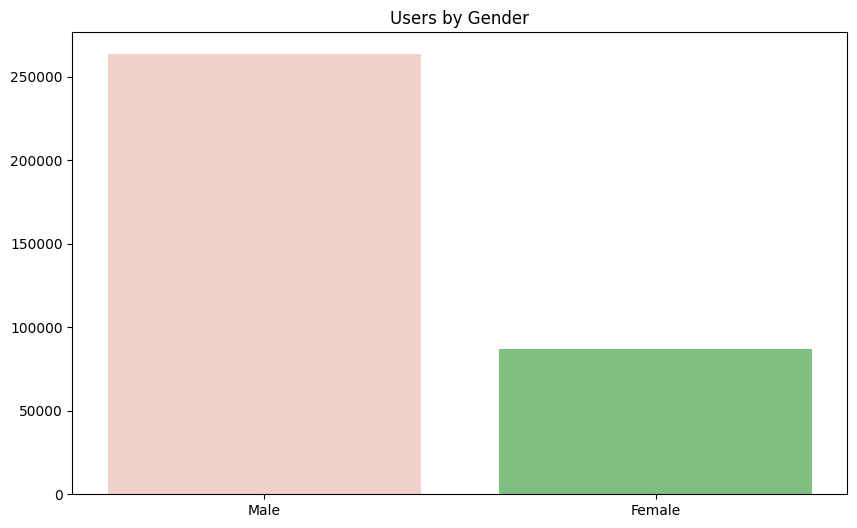

gender
Male      263430
Female     86968
Name: count, dtype: int64


In [60]:
# Better approach using pandas
gender_counts: pd.Series = trips["gender"].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    gender_counts.index.astype(str),
    gender_counts.values,
    color=["#e4a199", "green"],
    alpha=0.5,
)

ax.set_title("Users by Gender")

plt.show()

print(gender_counts)

<div style="border-left: 5px solid green; background-color: #e6ffe6; padding:10px;">
<strong>Interpretación "hombres vs mujeres":</strong>Esto no significa que 263430 hombre usaron las bicicletas y que 86 968 mujeres usaron las bicicletas, sino que en total 263430 registros que son de varones y 86 968 registros de mujeres
</div>

### Basados en el gráfico anterior, quién usa más bicicletas, hombres o mujeres?
#### A. Mujeres
#### B. Hombres
#### C. No se puede determinar

In [ ]:
### edTest(test_chow3) ###
# Submit an answer choice as a string below (eg. if you choose option A, put 'A')
answer3 = 'B'

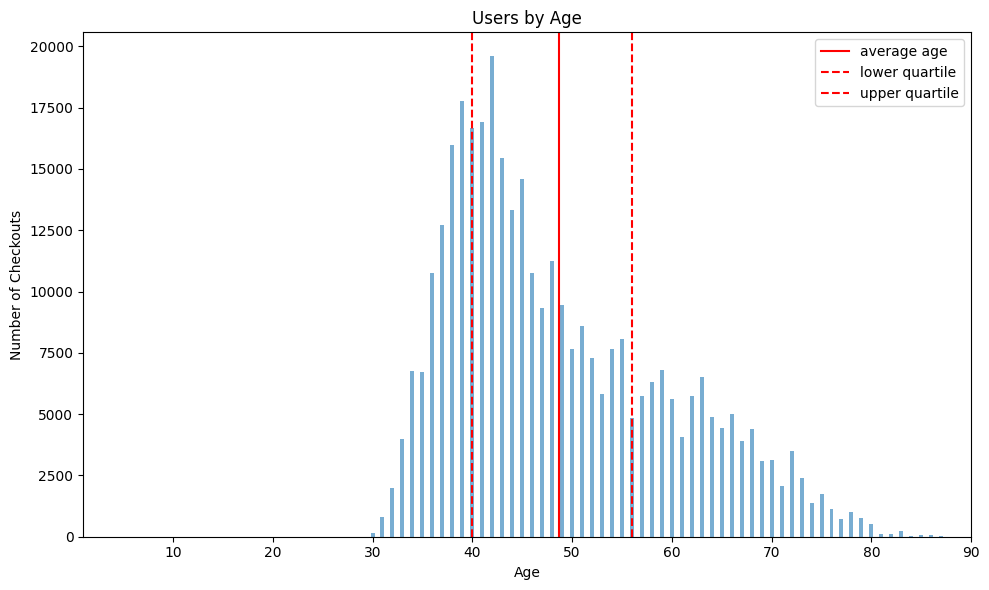

[  151   790  1972  3969  6766  6716 10773 12720 15989 17791 16657 16904
 19592 15435 13306 14570 10774  9310 11263  9469  7665  8602  7303  5817
  7649  8078  4843  5724  6311  6783  5609  4051  5735  6530  4879  4436
  4987  3922  4406  3100  3118  2076  3491  2381  1393  1746  1125   739
  1013   757   513   130   130   213    19    79    82    34     6     6]
[30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47.
 48. 49. 50. 51. 52. 53. 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65.
 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83.
 84. 85. 86. 87. 91. 93.]


In [ ]:
# Count how many trips are associated with each rider age
age_counts: pd.Series = trips["age"].value_counts().sort_index()

# mean_age: promedio de edad
# lower_quartile: 25% de usuarios tienen edad menor o igual a este valor
# upper_quartile: 75% de usuarios tienen edad menor o igual a este valor

# Compute summary statistics for age
mean_age: float = float(trips["age"].mean())
lower_quartile: float = float(trips["age"].quantile(0.25))
upper_quartile: float = float(trips["age"].quantile(0.75))



# Create figure and axis
fig: plt.Figure
ax: plt.Axes
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot bar chart of rider ages
ax.bar(
    age_counts.index,
    age_counts.values,
    align="center",
    width=0.4,
    alpha=0.6
)

# Add vertical reference lines
ax.axvline(x=mean_age, color="red", label="average age")
ax.axvline(x=lower_quartile, color="red", linestyle="--", label="lower quartile")
ax.axvline(x=upper_quartile, color="red", linestyle="--", label="upper quartile")

# Configure plot
ax.set_xlim([1, 90])
ax.set_xlabel("Age")
ax.set_ylabel("Number of Checkouts")
ax.set_title("Users by Age")
ax.legend()

plt.tight_layout()
plt.show()

# Print frequencies and corresponding ages
print(age_counts.values)
print(age_counts.index.to_numpy())

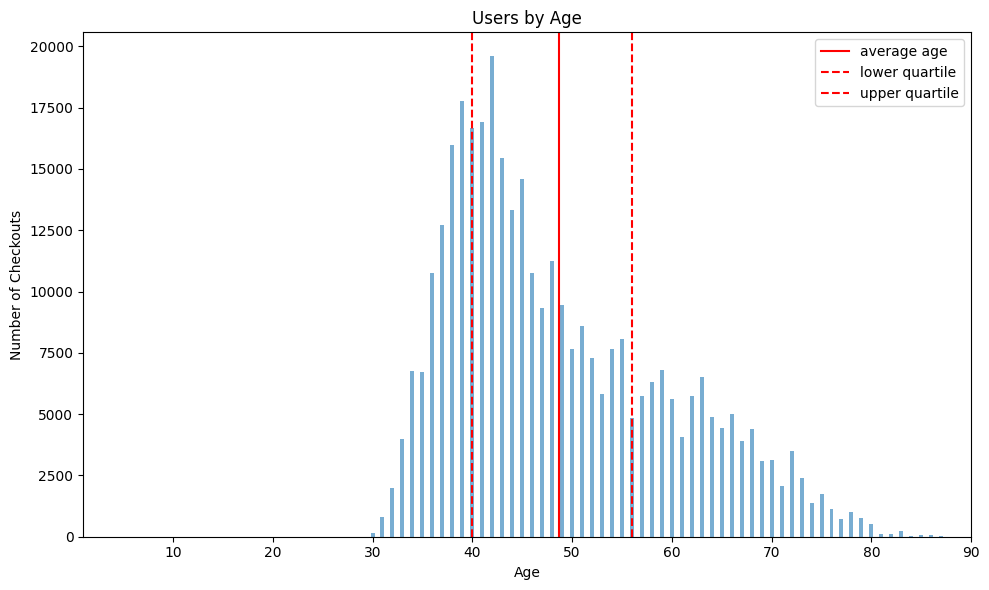

[  151   790  1972  3969  6766  6716 10773 12720 15989 17791 16657 16904
 19592 15435 13306 14570 10774  9310 11263  9469  7665  8602  7303  5817
  7649  8078  4843  5724  6311  6783  5609  4051  5735  6530  4879  4436
  4987  3922  4406  3100  3118  2076  3491  2381  1393  1746  1125   739
  1013   757   513   130   130   213    19    79    82    34     6     6]
[30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47.
 48. 49. 50. 51. 52. 53. 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65.
 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83.
 84. 85. 86. 87. 91. 93.]


In [61]:
# Plotting the usage of bikes based on the ages of riders
fig, ax = plt.subplots(1,1, figsize=(10, 6))
age_counts = np.unique(trips['age'], return_counts=True)
ax.bar(age_counts[0], age_counts[1], align='center', width=0.4, alpha=0.6)
ax.axvline(x=np.mean(age_col), color='red', label='average age')
ax.axvline(x=np.percentile(age_col, 25), color='red', linestyle='--', label='lower quartile')
ax.axvline(x=np.percentile(age_col, 75), color='red', linestyle='--', label='upper quartile')
ax.set_xlim([1, 90])
ax.set_xlabel('Age')
ax.set_ylabel('Number of Checkouts')
ax.legend()
ax.set_title('Users by Age')
plt.tight_layout()

# mostrar figura
plt.show()
print(age_counts[1])
print(age_counts[0])

### ⏸ Basados en el gráfico anterior, quién usa más bicletas, gente joven o mayor?
#### A. Mayor
#### B. Jóvenes

In [ ]:
### edTest(test_chow4) ###
# Submit an answer choice as a string below (eg. if you choose option A, put 'A')
answer4 = 'B'


# **¿Cuándo? ¿Cuándo se prestan las bicicletas?**

*  ¿Se usan más bicicletas durante el fin de semana que entre semana?
    -   Agrupar los datos por día de la semana y comparar el volumen de viajes.
*  ¿Se usan más en hora punta (mañana/tarde)?
    -  Analizar el número de viajes por hora del día
*  ¿Se usan más en verano que en otoño?
    -  Agrupar los viajes por mes o por estación del año.


In [ ]:
# Obtener el número de préstamos (checkouts) de bicicletar por hora
# Para encontrar la hora del día, usaremos la columna start_date y extraemos las horas.

check_out_hours = trips['start_date'].apply(lambda s: int(s[-8:-6]))

# Plotting los préstamos de bicicletar por hora
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
check_out_counts = np.unique(check_out_hours, return_counts=True)
ax.bar(check_out_counts[0], check_out_counts[1], align='center', width=0.4, alpha=0.6)
ax.set_xlim([-1, 24])
ax.set_xticks(range(24))
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Checkouts')
ax.set_title('Time of Day vs Checkouts')
plt.show()

# print number of checkouts by hour
print(check_out_counts[1])
print(check_out_counts[0])


###  Según la gráfica, ¿en qué momento se registra la mayor congestión de usuarios?

In [ ]:
### edTest(test_chow5) ###
# Submit the integer value below within the quotes
answer5 = '17'


# **¿Dónde? ¿Dónde se prestan las bicicletas?**
Refinar en hipótesis específicas:

* ¿Más en Boston que en Cambridge?
* ¿Más en zonas comerciales o residenciales?
* ¿Más cerca de las atracciones turísticas?


In [ ]:
import pandas as pd
station_data = pd.read_csv("dataset/hubway_stations.csv", low_memory = False)[['id', 'lat', 'lng']]
hubway_data = pd.read_csv("dataset/hubway_trips.csv")
station_data.head()

In [ ]:
hubway_data_with_gps = hubway_data.join(station_data.set_index('id'), on='strt_statn')
hubway_data_with_gps.head(30)

In [ ]:
import folium
from folium.plugins import HeatMap

# Filtramos viajes con coordenadas válidas
heat_df = hubway_data_with_gps[['lat', 'lng']].dropna()

# Convertimos a lista de puntos
heat_points = heat_df.values.tolist()

# Creamos un mapa centrado en Boston
mapa = folium.Map(location=[42.3601, -71.0589], zoom_start=13)

# Añadimos el HeatMap
HeatMap(heat_points, radius=8, blur=15).add_to(mapa)

# Mostramos el mapa
mapa

#### ¿MÁS PREGUNTAS?

Hay muchas preguntas que no se han abordado aquí.

1. ¿Para qué fines se están utilizando las bicicletas? ¿Recreación, transporte o beneficios para la salud?
2. ¿El uso es mayor durante los días de semana o los fines de semana?


### **EXPLORATORY DATA ANALYSIS (EDA)**

La información extraída anteriormente no es suficiente para responder a la mayoría de las preguntas y, definitivamente, no es suficiente para plantear preguntas relevantes. Por lo tanto, necesitaremos realizar análisis de datos adicionales.

In [ ]:
# Encuentre si hay alguna relación entre las variables predictoras en los datos de las estaciones.
sns.pairplot(stations);

#mostrar figura
plt.show()

### Según el gráfico anterior, ¿nota alguna relación reconocible entre alguna de las columnas?

#### A. La latitud y la longitud son directamente proporcionales entre sí.
#### B. La latitud y la longitud son inversamente proporcionales entre sí.
#### C. Es aleatorio. Parece no haber relación entre la latitud y la longitud.

In [ ]:
### edTest(test_chow2) ###
# Submit an answer choice as a string below (eg. if you choose option A, put 'A')
answer2 = 'C'


### **MODELADO DE DATOS**
Hay algunas preguntas que no pueden responderse únicamente con técnicas gráficas simples. Requieren combinar diferentes variables.


1. ¿Cómo afectan los datos demográficos de los usuarios a la duración del uso de las bicicletas o al lugar donde se retiran?

2. ¿Cómo influyen las condiciones climáticas o del tráfico en el uso de las bicicletas?

3. ¿Cómo afectan las características de la ubicación de la estación al número de bicicletas que se retiran?




Intentemos responder la siguiente pregunta:


# **<center>¿Cómo afecta la distancia desde el centro de la ciudad al uso de las bicicletas? </center>**

Esta pregunta responde a:

*¿Qué relación existe entre la distancia de una estación al centro de la ciudad y la cantidad de veces que se utiliza (checkouts)?*

Pasos:

A.  Importar las librerias necesarias.

B.  Cargar los datos.

C.  Limpieza y preprocesamiento.

D.  Agrupar y resumir los datos.

E. Ajustar el modelo.

F. Realizar predicciones.

G. Visualizar los resultados




**C. Limpieza y preprocesamiento**


*   Verificar valores nulos, tipos de datos.
*   Renombrar columnas si es necesario.
*   Calcular columnas nuevas (ej: distancias al centro).
    -  Calcular la distancia desde la estación de devolución de bicicletas (chekout) al cetro de Boston:

        1. Establecer las coordenadas del centro de la ciudad (Boston como referencia).
        2. Unir coordenadas de la estación final al DataFrame de viajes.
        3. Calcular distancia Haversine en km.
        4. Calcular distancia desde cada estación final al centro.

**D. Agrupar y resumir los datos.**
*   Cómo medimos el uso de bicicletas?, cuantificando el uso de bicicletas dependiendo de la distan desde el centro de la ciudad:
  1. Calcular número de checkouts por estación final.
  2. Seleccionar columnas relevantes del DataFrame de estaciones.
  3. Unir los dos DataFrames en uno solo.

**E. Ajustar el modelo**
1.   Preparar los datos sin valores nulos.
2.   Ajustar el modelo lineal.
3.   Predecir para 2.5 millas.




In [ ]:
# C.1. Coordenadas del centro de Boston
center_lat = 42.355
center_lon = -71.065

In [ ]:
# C.2. Unir los datos de los viajes con las coordenadas de la estación final
# agregar las coordenadas (latitud y longitud) de cada estación final (end_station) a la tabla de viajes (trips), para que luego puedas calcular distancias o hacer visualizaciones.
#  unir los datos de trips (viajes) con los datos de stations (estaciones), donde el end_station_id de un viaje coincide con el id de una estación.”

trips = trips.merge(   # Junta los DataFrames trips y stations, parecido a una JOIN en SQL.
    stations[['id', 'lat', 'lng']],  # De todo el DataFrame stations, selecciona solo las columnas:id → el identificador único de cada estación.lat, lon → latitud y longitud de cada estación.
    how='left', # indica una left join (unión por la izquierda):Conserva todas las filas de trips.Si encuentra coincidencia en stations, trae los datos (lat, lon). Si no encuentra coincidencia, deja NaN.
    left_on='end_statn',   #Usa la columna end_station_id del DataFrame izquierdo (trips) para emparejar
    right_on='id'   # Usa la columna id del DataFrame derecho (stations) para emparejar
)

# Obtienes un nuevo DataFrame trips que ahora incluye las columnas lat y lon de la estación de devolución de bicicletas (end_station_id), lo cual te permite calcular distancias, hacer mapas, etc.




In [ ]:
trips

In [ ]:
# C.3. Función para calcular la distancia Haversine
# Haversine considera la curvatura de la Tierra
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c


In [ ]:
# C.4. Calcular la distancia al centro
trips['dist_to_center'] = haversine(
    trips['lat'], trips['lng'], center_lat, center_lon)

In [ ]:
trips

In [ ]:
# D.1. Calcular número de checkouts por estación final
checkouts = trips.groupby('end_statn').agg(
    checkouts=('end_statn', 'count'),
    dist_to_center=('dist_to_center', 'mean')
).reset_index()

In [ ]:
# D.2. Seleccionar columnas relevantes del DataFrame de estaciones
stations_info = stations[['id', 'terminal', 'station', 'municipal', 'lat', 'status', 'lng']].copy()
stations_info.rename(columns={'lon': 'lng'}, inplace=True)

In [ ]:
# D.3. Unir los dos DataFrames en uno solo

counts_df = stations_info.merge(
    checkouts,
    how='left',
    left_on='id',
    right_on='end_statn'
)

In [ ]:
counts_df

**E. Ajustar el modelo.**

Para estimar el número de checkout  desde el centro de la ciudad usaremos una línea recta y = ax + b para modelar la relación entre el checout y la distancia al centro de la ciudad. Para tal efecto, usamos el modelo de regresión lineal:

<center> checkouts=β0  + β1 ⋅distance </center>

- La variable dependiente es checkouts (uso del sistema).

- La variable independiente es* dist_to_center* (ubicación relativa).


Qué nos dirá el modelo?
Para cada milla adicional de distancia desde el centro de la ciudad, el número de checkouts podría disminuir o aumentar


In [ ]:
beta0 = 20900
beta1 = -1375

y_pred = beta0 + beta1 * counts_df['dist_to_center'].values

Si deseamos ajustar el modelo, debemos seguir los siguientes pasos:

*   Paso 1: Ajustar el modelo lineal:

        1.   Preparar los datos sin valores nulos.
        2.   Ajustar el modelo lineal.
        3.   Predecir para 2.5 millas.


*   Paso 2: Graficar:

        4. La recta del modelo
        5. El valor estimado para 2.5 millas (punto rojo).
        



In [ ]:
# Ajustar el modelo lineal
# 1. Asegurar de que no haya valores nulos
counts_df.info()
df = counts_df.dropna(subset=['dist_to_center', 'checkouts'])



¿Qué hará el modelo?

*   Ajustar una regresión lineal simple.
*   Usar como variable independiente: dist_to_center.
*   Estimar la cantidad esperada de checkouts para una distancia de 2.5 millas.



In [ ]:
# E.1. Calcular el modelo lineal

# Variables
X = df[['dist_to_center']]
y = df['checkouts']

# E.2.  Ajustar modelo lineal
model = LinearRegression()
model.fit(X, y)



In [ ]:
# F. Realizar Predicciones

# Predecir checkouts para 2.5 millas
distance_input = 2.5
predicted_checkouts = model.predict([[distance_input]])[0]
print(f"Predicted checkouts at 2.5 miles: {predicted_checkouts:.2f}")

In [ ]:
#G. Graficar
plt.figure(figsize=(10,6))
sns.scatterplot(x='dist_to_center', y='checkouts', data=counts_df, label='Datos reales', color='blue')

# Línea de regresión
x_vals = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_vals = model.predict(x_vals)
plt.plot(x_vals, y_vals, color='black', label='Modelo lineal')

# Punto estimado para 2.5 millas
plt.scatter(distance_input, predicted_checkouts, color='red', s=100, zorder=5, label=f'Predicción (2.5 mi): {predicted_checkouts:.0f} checkouts')

# Etiquetas
plt.title('Relación entre distancia y número de checkouts')
plt.xlabel('Distancia al centro (millas)')
plt.ylabel('Número de checkouts')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
### edTest(test_chow6) ###
# Submit an answer choice as a string below (eg. if you choose option A, put 'A')
answer6 = 'C'


###  ¿Cuál sería el número probable de checkouts para una distancia de 2.5 millas desde el centro de la ciudad??
#### A. 45000
#### B. 4082
#### C. 1450
#### D. 650


**Conclusión:**
Este análisis ayuda a tomar decisiones basadas en datos para optimizar la ubicación de estaciones y mejorar la cobertura del sistema.

___